## 1. Carregamento

In [2]:
import pandas as pd
import glob

In [3]:
# Carregar todos os CSVs de uma vez
files = glob.glob('../data/raw/*.csv')
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


In [4]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.head(3))

(6209268, 13)
ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id          str
end_station_name          str
end_station_id            str
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object
ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1299069
start_station_id      1299069
end_station_name      1368520
end_station_id        1368520
start_lat                   0
start_lng                   0
end_lat                  6143
end_lng                  6143
member_casual               0
dtype: int64
            ride_id  rideable_type               started_at  \
0  7569BC890583FCD7   classic_bike  2025-01-21 17:23:54.538   
1  013609308856B7FC  electric_bike  2025-01-11 15:44:

In [5]:
# Investigar: nulos de estação são de qual tipo de bike?
print(df[df['start_station_name'].isnull()]['rideable_type'].value_counts())

# E a distribuição geral de tipos de bike
print(df['rideable_type'].value_counts())

rideable_type
electric_bike    1299069
Name: count, dtype: int64
rideable_type
electric_bike    4054262
classic_bike     2155006
Name: count, dtype: int64


#### decidi não dropar os valores nulos e criar uma flag 'has_station' para as electric_bikes sem start_station_name

## 2. Limpeza

In [6]:
# convertendo datas
df_clean = df.copy()

df_clean['started_at'] = pd.to_datetime(df_clean['started_at'])
df_clean['ended_at'] = pd.to_datetime(df_clean['ended_at'])

In [ ]:
# Criar a flag
df_clean['has_station'] = (
    df_clean['start_station_name'].notna() &
    df_clean['end_station_name'].notna()
).astype(int)

# Verificação
print(df_clean['has_station'].value_counts(normalize=True).round(3))

# Cruzar com membre_casual
print(pd.crosstab(df_clean['member_casual'], df_clean['has_station'], normalize='index').round(3))

has_station
1    0.67
0    0.33
Name: proportion, dtype: float64
has_station        0      1
member_casual              
casual         0.336  0.664
member         0.327  0.673


In [ ]:
df_clean = df_clean.dropna(subset=['end_lat', 'end_lng'])
print(df_clean.shape)

(6209268, 13)


## 3. Feature Engineering

In [9]:
# Duração da viagem em minutos
df_clean['duration_min'] = (df_clean['ended_at'] - df_clean['started_at']).dt.total_seconds() / 60

print(df_clean['duration_min'].describe())
print(f"\nNegativos: {(df_clean['duration_min'] < 0).sum()}")
print(f"Menos de 1 min: {(df_clean['duration_min'] < 1).sum()}")
print(f"Mais de 12h: {(df_clean['duration_min'] > 720).sum()}")

count    6.203125e+06
mean     1.429729e+01
std      2.971974e+01
min     -5.479480e+01
25%      5.277250e+00
50%      9.206600e+00
75%      1.618648e+01
max      1.499968e+03
Name: duration_min, dtype: float64

Negativos: 29
Menos de 1 min: 163555
Mais de 12h: 2685


In [10]:
df_clean = df_clean[
    (df_clean['duration_min'] >= 1) &
    (df_clean['duration_min'] <= 720)
]


In [11]:
# Componentes temporais
df_clean['hour'] = df_clean['started_at'].dt.hour
df_clean['day_of_week'] = df_clean['started_at'].dt.dayofweek # 0 = segunda, 6 = domingo
df_clean['month'] = df_clean['started_at'].dt.month
df_clean['is_weekend'] = df_clean['day_of_week'].isin([5, 6]).astype(int)

print(df_clean[['duration_min', 'hour', 'day_of_week', 'month', 'is_weekend']].head())
print(df_clean.shape)

   duration_min  hour  day_of_week  month  is_weekend
0     13.957950    17            1      1           0
1      5.072400    15            5      1           1
2     11.591667    15            3      1           0
3      3.570550     8            3      1           0
4      2.573817     8            3      1           0
(6036885, 19)


## 4. EDA dirigida nas hipoteses

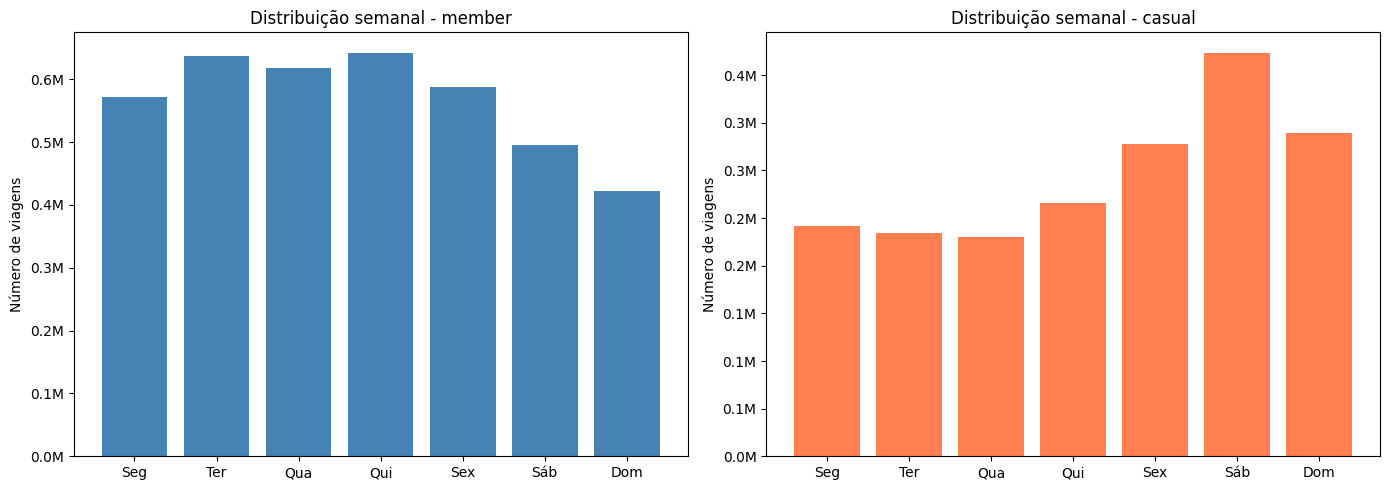

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# H1/H2 - Distribuição por dia da Semana

days = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

for ax, profile in zip(axes, ['member', 'casual']):
    data = df_clean[df_clean['member_casual'] == profile]
    counts = data['day_of_week'].value_counts().sort_index()
    ax.bar(days, counts.values, color='steelblue' if profile == 'member' else 'coral')
    ax.set_title(f'Distribuição semanal - {profile}')
    ax.set_ylabel('Número de viagens')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))


plt.tight_layout()
plt.savefig('../charts/h1_h2_weekly.png', dpi=150)
plt.show()

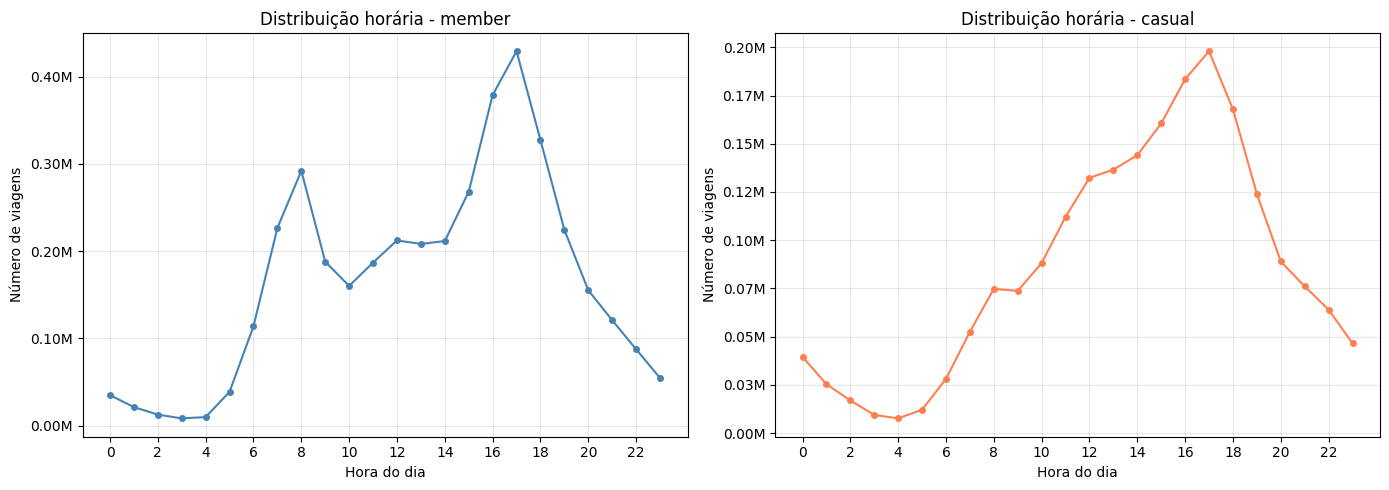

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hours = range(24)

for ax, profile in zip(axes, ['member', 'casual']):
    data = df_clean[df_clean['member_casual'] == profile]
    counts = data['hour'].value_counts().sort_index()
    ax.plot(counts.index, counts.values, marker='o', markersize=4,
            color='steelblue' if profile == 'member' else 'coral')
    ax.set_title(f"Distribuição horária - {profile}")
    ax.set_xlabel("Hora do dia")
    ax.set_ylabel('Número de viagens')
    ax.set_xticks(range(0, 24, 2))
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M')
    )
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../charts/h5_hourly.png', dpi=150)
plt.show()

In [14]:
# Duração mediana por perfil
duration = df_clean.groupby('member_casual')['duration_min'].median()
print(duration)

# E por dia da semana + perfil

duration_week = df_clean.groupby(
    ['member_casual', 'is_weekend']
)['duration_min'].median().round(2)

print(duration_week)

member_casual
casual    11.634250
member     8.583583
Name: duration_min, dtype: float64
member_casual  is_weekend
casual         0             10.68
               1             13.57
member         0              8.42
               1              9.17
Name: duration_min, dtype: float64


## Clusterização

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

In [16]:
# Selecionar features
features = ['duration_min', 'hour', 'day_of_week', 'month']
X = df_clean[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Média após scaling", X_scaled.mean(axis=0).round(3))
print("Std após scaling", X_scaled.std(axis=0).round(3))

Média após scaling [ 0.  0. -0.  0.]
Std após scaling [1. 1. 1. 1.]


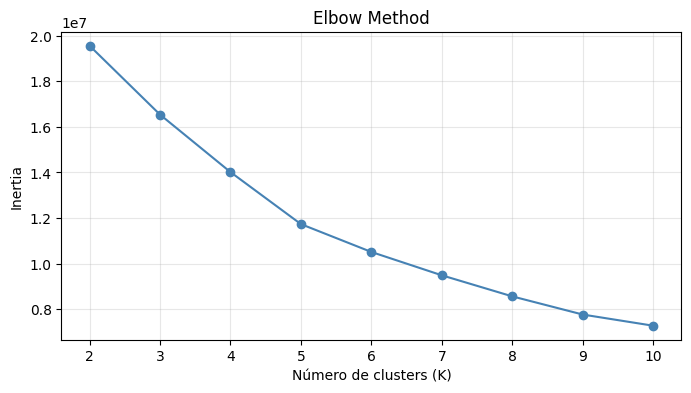

In [17]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.savefig('../charts/elbow.png', dpi=150)
plt.show()

In [20]:
# Rodar K-means com K=4

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

# Perfil de cada cluster
profile = df_clean.groupby('cluster')[features + ['member_casual']].agg({
    'duration_min' : 'median',
    'hour': 'median',
    'day_of_week': 'median',
    'month': 'median',
    'member_casual': lambda x: (x == 'casual').mean().round(3)
}).round(2)

profile.columns = ['duration_mediana', 'hora_mediana',
                   'dia_semana_mediana', 'mes_mediano', 'pct_casual']
print(profile)
print(f"\nTamanho dos clusters: \n{df_clean['cluster'].value_counts().sort_index()}")

         duration_mediana  hora_mediana  dia_semana_mediana  mes_mediano  \
cluster                                                                    
0                   10.54          15.0                 5.0          8.0   
1                    9.37          16.0                 1.0          8.0   
2                   90.19          14.0                 4.0          7.0   
3                    7.90          14.0                 3.0          3.0   

         pct_casual  
cluster              
0              0.42  
1              0.30  
2              0.80  
3              0.25  

Tamanho dos clusters: 
cluster
0    2385683
1    1718437
2      99411
3    1833354
Name: count, dtype: int64


In [ ]:
from sklearn.decomposition import PCA

Cluster 0: 19791 pontos
Cluster 1: 14291 pontos
Cluster 2: 857 pontos
Cluster 3: 15061 pontos


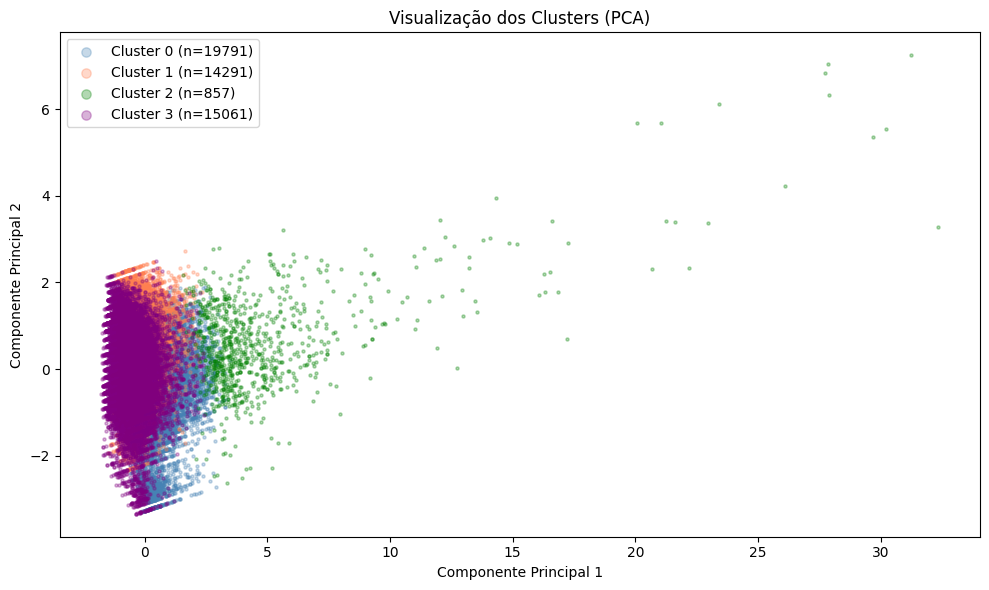


Variância explicada: [0.286 0.247]
Total: 0.533


In [28]:
# Abordagem limpa — tudo junto, sem risco de desalinhamento
np.random.seed(42)
idx = np.random.choice(len(df_clean), size=50000, replace=False)

X_sample = X_scaled[idx]
clusters_sample = df_clean['cluster'].iloc[idx].values  # .values remove o índice

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue', 'coral', 'green', 'purple']

for i in range(4):
    mask = clusters_sample == i
    print(f"Cluster {i}: {mask.sum()} pontos")  # debug
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[i], label=f'Cluster {i} (n={mask.sum()})',
               alpha=0.3, s=5)

ax.set_title('Visualização dos Clusters (PCA)')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../charts/clusters_pca_v3.png', dpi=150)
plt.show()

print(f"\nVariância explicada: {pca.explained_variance_ratio_.round(3)}")
print(f"Total: {pca.explained_variance_ratio_.sum().round(3)}")